# D1/D2 Dopamine Extension

Extension of the Q-learning maze by replacing the single learning rate α with two separate parameters:
- **α⁺** (alpha_pos): learning rate for positive prediction errors 
- **α⁻** (alpha_neg): learning rate for negative prediction errors 

Four agent profiles represent different dopaminergic states.

## Setup

In [7]:
import numpy as np
import matplotlib.pyplot as plt

maze = np.array([
    [0, 0, 1, 0, 0, 0],
    [0, 2, 0, 0, 1, 0],
    [0, 0, 0, 2, 0, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0],
    [2, 0, 1, 0, 0, 3]
])

ROWS, COLS = maze.shape
START = (0, 0)
GOAL  = (5, 5)
DIRS  = [(-1,0), (1,0), (0,-1), (0,1)]

gamma    = 0.9
epsilon  = 0.2
episodes = 500
N_RUNS   = 20

COLORS = {
    'balanced':            'blue',
    'reward seeking':      'green',
    'punishment avoidant': 'red',
    'low DA':              'gray',
}

# agent profiles: each has a distinct alpha_pos / alpha_neg
AGENT_PARAMS = {
    'balanced':            {'alpha_pos': 0.5, 'alpha_neg': 0.5},
    'reward seeking':      {'alpha_pos': 0.9, 'alpha_neg': 0.1},
    'punishment avoidant': {'alpha_pos': 0.1, 'alpha_neg': 0.9},
    'low DA':              {'alpha_pos': 0.1, 'alpha_neg': 0.1},
}

def step(state, action):
    r, c = state
    dr, dc = DIRS[action]
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS or maze[nr, nc] == 1:
        nr, nc = r, c
    tile = maze[nr, nc]
    if tile == 3:
        reward = 10
    elif tile == 2:
        reward = -1
    else:
        reward = -0.04
    done = (tile == 3 or tile == 2)
    return (nr, nc), reward, done

def choose_action(state, Q):
    r, c = state
    if np.random.random() < epsilon:
        return np.random.randint(4)
    else:
        return np.argmax(Q[r, c])


## Training

Each agent is trained for 500 episodes across 20 runs. Results are averaged across runs.

In [8]:
results = {name: {} for name in AGENT_PARAMS}

for name, params in AGENT_PARAMS.items():
    alpha_pos = params['alpha_pos']
    alpha_neg = params['alpha_neg']

    all_steps  = []
    all_deltas = []

    for run in range(N_RUNS):
        np.random.seed(run)   # random seed each run
        Q = np.zeros((ROWS, COLS, 4))   # reset Q table each run

        run_steps  = []
        run_deltas = []

        for episode in range(episodes):
            state     = START
            steps     = 0
            ep_deltas = []

            while True:
                r, c   = state
                action = choose_action(state, Q)
                next_state, reward, done = step(state, action)
                nr, nc = next_state

                delta = reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action]

                # split alpha value 
                if delta > 0:
                    Q[r, c, action] += alpha_pos * delta   # D1: positive prediction error learning
                else:
                    Q[r, c, action] += alpha_neg * delta   # D2: negative prediction error learning

                ep_deltas.append(delta)
                steps += 1
                state = next_state

                if done or steps > 500:
                    break

            run_steps.append(steps)
            run_deltas.append(np.mean(ep_deltas))

        all_steps.append(run_steps)
        all_deltas.append(run_deltas)

    results[name]['Q']          = Q
    results[name]['steps']      = np.mean(all_steps,  axis=0)
    results[name]['deltas']     = np.mean(all_deltas, axis=0)
    results[name]['steps_std']  = np.std(all_steps,   axis=0)
    results[name]['deltas_std'] = np.std(all_deltas,  axis=0)

print('Training complete.')


Training complete.


## Results

### Learning Curves and TD Error

Steps to goal and mean TD error per episode, averaged across 20 runs. Shaded bands show ±1 SD.

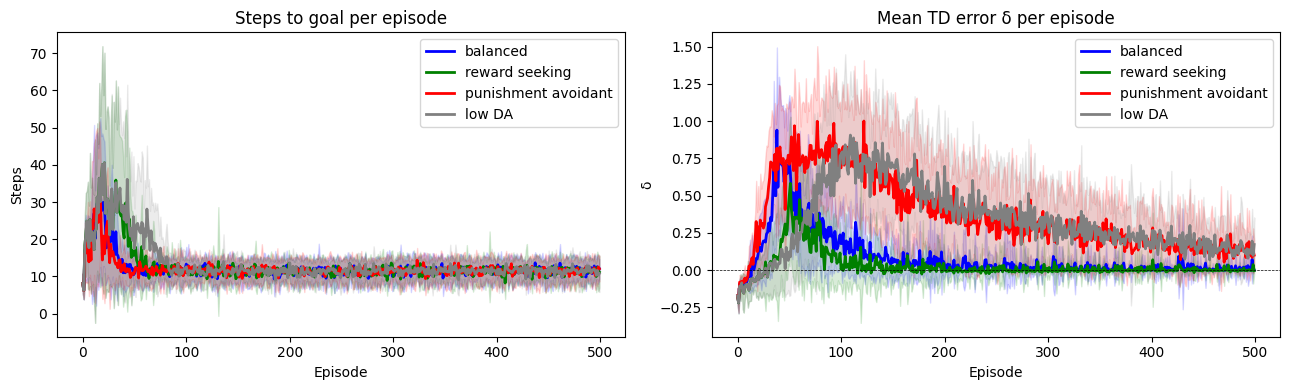

In [9]:
x = np.arange(episodes)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# steps to goal
for name in AGENT_PARAMS:
    mean = results[name]['steps']
    std  = results[name]['steps_std']
    axes[0].plot(x, mean, color=COLORS[name], label=name, linewidth=2)
    axes[0].fill_between(x, mean - std, mean + std,
                         color=COLORS[name], alpha=0.15)
axes[0].set_title('Steps to goal per episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Steps')
axes[0].legend()

# mean TD error per episode
for name in AGENT_PARAMS:
    mean = results[name]['deltas']
    std  = results[name]['deltas_std']
    axes[1].plot(x, mean, color=COLORS[name], label=name, linewidth=2)
    axes[1].fill_between(x, mean - std, mean + std,
                         color=COLORS[name], alpha=0.15)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Mean TD error δ per episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('δ')
axes[1].legend()

plt.tight_layout()
plt.show()


### Q-Value Heatmaps

Max Q-value per state (best action) after training. Black cells are walls.

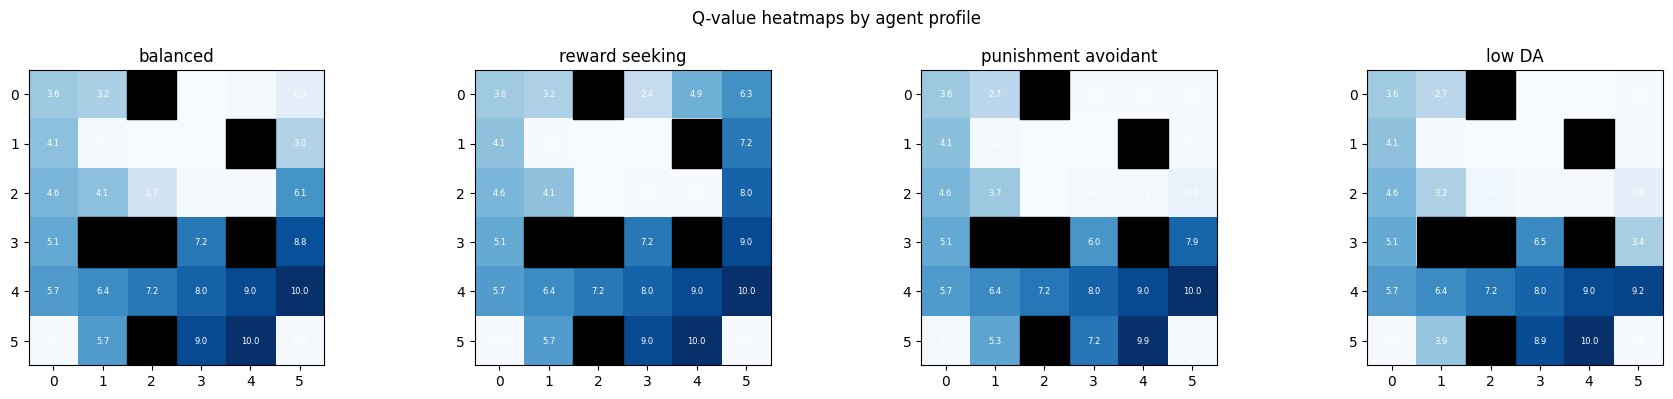

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, name in zip(axes, AGENT_PARAMS):
    Q         = results[name]['Q']
    value_map = np.max(Q, axis=2)
    ax.imshow(value_map, cmap='Blues')
    ax.set_title(f'{name}')
    for r in range(ROWS):
        for c in range(COLS):
            if maze[r, c] == 1:
                ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='black'))
            else:
                ax.text(c, r, f'{value_map[r,c]:.1f}',
                        ha='center', va='center', fontsize=6, color='white')

plt.suptitle('Q-value heatmaps by agent profile', fontsize=12)
plt.tight_layout()
plt.show()


### TD Error by Agent

Mean TD error per episode per agent. Green = positive prediction error, red = negative prediction error.

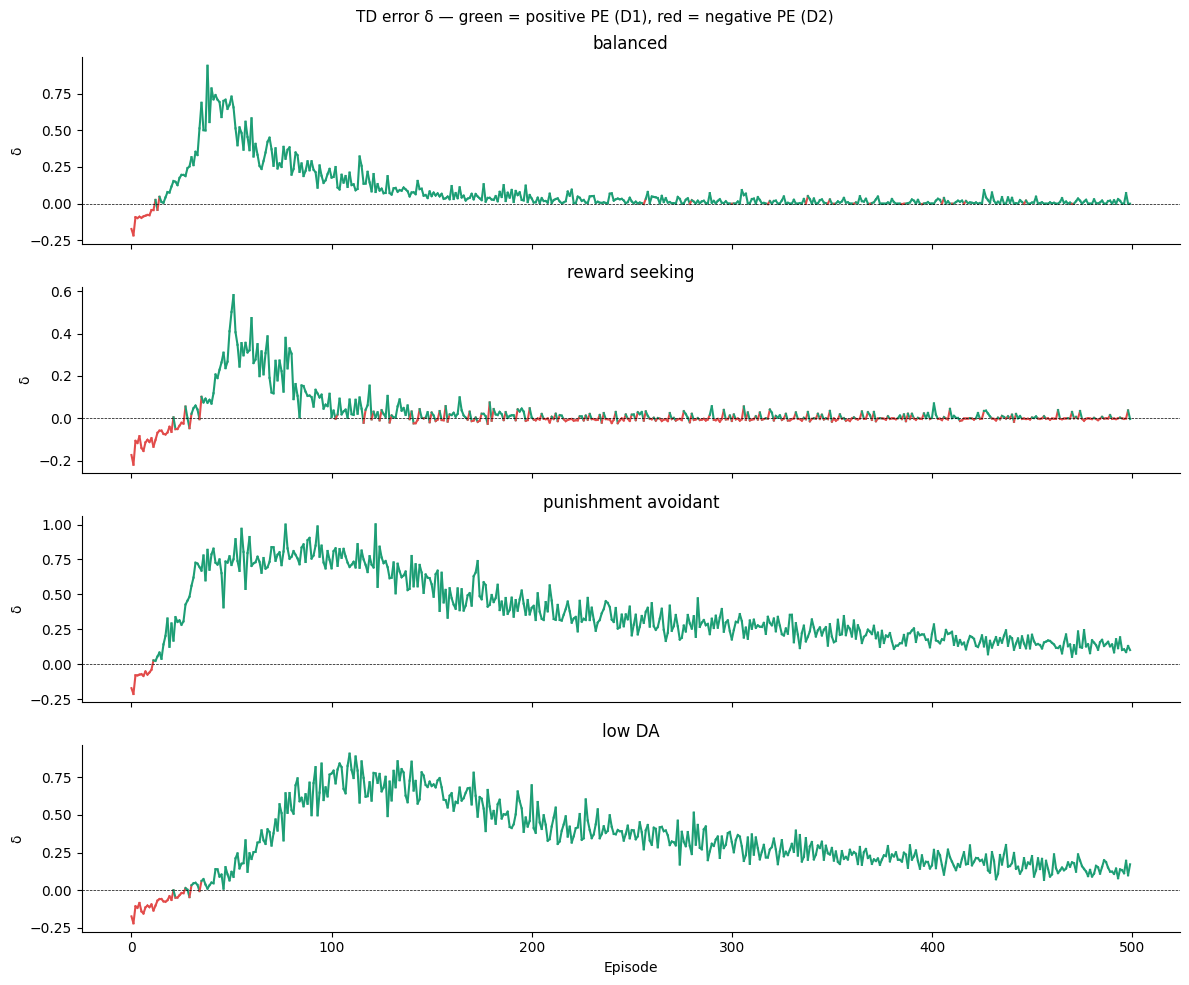

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for ax, name in zip(axes, AGENT_PARAMS):
    smoothed = results[name]['deltas']
    x = np.arange(len(smoothed))

    for i in range(len(smoothed) - 1):
        color = '#1D9E75' if smoothed[i] > 0 else '#E24B4A'
        ax.plot([x[i], x[i+1]], [smoothed[i], smoothed[i+1]],
                color=color, linewidth=1.5)

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_ylabel('δ')
    ax.set_title(name)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Episode')
plt.suptitle('TD error δ — green = positive PE (D1), red = negative PE (D2)', fontsize=11)
plt.tight_layout()
plt.show()
